In [11]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import os

DATA_DIR = Path("/content/drive/MyDrive/STATS201_project/torres_replication/")
CAPSULE_DATA = DATA_DIR / "capsule" / "data"
IMAGES_DIR = CAPSULE_DATA / "Images2"

print("DATA_DIR exists:", DATA_DIR.exists())
print("Images dir exists:", IMAGES_DIR.exists())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DATA_DIR exists: True
Images dir exists: True


In [31]:
import numpy as np
import pandas as pd

import cv2

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_recall_fscore_support, f1_score, ConfusionMatrixDisplay
)


In [13]:
meta_path = CAPSULE_DATA / "metadata_caravan_media_short.csv"
clusters_path = CAPSULE_DATA / "clusters_preds_caravan_newsapi.csv"

meta = pd.read_csv(meta_path, encoding="latin1")
clusters = pd.read_csv(clusters_path)

# clusters: file, predicted_labels
# meta: imageid, iscrowd

clusters["imageid"] = clusters["file"].astype(str).str.replace(r"\.p$", "", regex=True)

df = meta.merge(clusters[["imageid", "predicted_labels"]], on="imageid", how="inner")
df["y"] = df["iscrowd"].astype(int)

print("Merged df:", df.shape)
print("y distribution:", df["y"].value_counts(normalize=True).to_dict())
df[["imageid","predicted_labels","y"]].head()

Merged df: (517, 17)
y distribution: {0: 0.7891682785299806, 1: 0.21083172147001933}


,imageid,predicted_labels,y
0,abc-news_0000_11.jpg,3,0
1,abc-news_0001_1.jpg,7,0
2,abc-news_0002_1.jpg,6,0
3,abc-news_0003_2.jpg,5,0
4,abc-news_0003_3.jpg,8,0


In [14]:
def find_image_path(imageid: str):
    # Construct the image path by matching the imageid directly (imageid is the file name)
    p = IMAGES_DIR / f"{imageid}"  # No extension needed, as imageid already matches the file name

    # Check if the file exists and return the path
    if p.exists():
        return str(p)
    else:
        print(f"No matches found for {imageid}")
        return None
df["image_path"] = df["imageid"].astype(str).apply(find_image_path)

print("Images found:", df["image_path"].notna().sum(), "/", len(df))
df[df["image_path"].isna()][["imageid"]].head()

Images found: 517 / 517


,imageid


In [15]:
!pip install facenet-pytorch
import os, math, time
import torch
from PIL import Image
import matplotlib.pyplot as plt
from facenet_pytorch import MTCNN, InceptionResnetV1
from PIL import Image
import matplotlib.pyplot as plt
import torch


In [16]:
torch.manual_seed(0)
np.random.seed(0)

# By including this line, cuda will be used automatically, but only if available
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cpu


In [17]:
# Define a Matplotlib function that shows an image with a header (optional)
def show_img(img, title=None, figsize=(5,5)):
    plt.figure(figsize=figsize)
    if isinstance(img, Image.Image):
        plt.imshow(img)
    else:
        plt.imshow(img, cmap="gray" if (hasattr(img, "ndim") and img.ndim == 2) else None)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()

In [18]:
# Load the pretrained models
from facenet_pytorch import MTCNN, InceptionResnetV1

mtcnn = MTCNN(image_size=160, margin=20, keep_all=True, device=device)
embedder = InceptionResnetV1(pretrained="vggface2").eval().to(device)

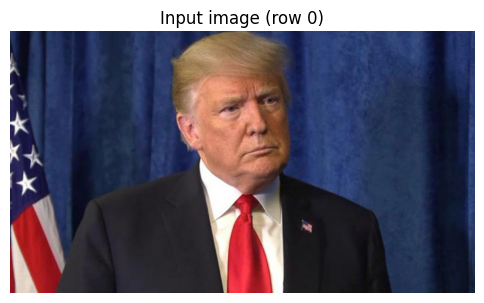

num faces: 1
boxes: [[389.09490966796875 54.248783111572266 602.8991088867188
  328.07135009765625]]


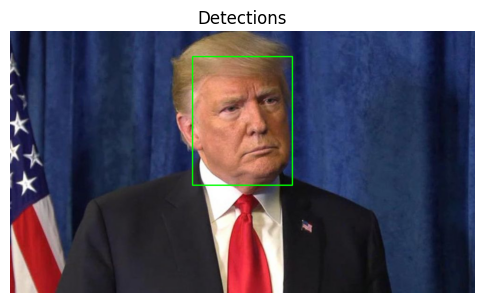

In [19]:
# Pick one row to visually confirm detections
i = 0
img_path = df.loc[i, "image_path"]

img_pil = Image.open(img_path).convert("RGB")
show_img(img_pil, title=f"Input image (row {i})", figsize=(6,6))

boxes, probs = mtcnn.detect(img_pil)
print("num faces:", 0 if boxes is None else len(boxes))
print("boxes:", boxes)

# Draw boxes like in class
img_np = np.array(img_pil).copy()
if boxes is not None:
    for (x1, y1, x2, y2) in boxes:
        x1, y1, x2, y2 = [int(v) for v in (x1, y1, x2, y2)]
        cv2.rectangle(img_np, (x1,y1), (x2,y2), (0,255,0), 2)

show_img(img_np, title="Detections", figsize=(6,6))


In [20]:
from PIL import Image
import time

def detect_faces_one(path, prob_thr=0.90):
    """
    Returns: face_count, face_count_hi, max_face_prob
    face_count (how many faces detected)
    face_count_hi (how many faces with high confidence)
    max_face_prob (best face confidence)
    """
    try:
        img = Image.open(path).convert("RGB")
        boxes, probs = mtcnn.detect(img)

        if boxes is None or probs is None:
            return 0, 0, 0.0

        probs = np.array(probs, dtype=float)
        face_count = int(len(probs))
        face_count_hi = int((probs >= prob_thr).sum())
        max_face_prob = float(probs.max()) if face_count > 0 else 0.0
        return face_count, face_count_hi, max_face_prob
    except Exception:
        return 0, 0, 0.0


t0 = time.time()

out = []
for i, p in enumerate(df["image_path"].tolist()):
    out.append(detect_faces_one(p, prob_thr=0.90))
    if (i+1) % 50 == 0:
        print(f"done {i+1}/{len(df)}")

df[["face_count", "face_count_hi", "max_face_prob"]] = pd.DataFrame(out, index=df.index)

print("time (sec):", round(time.time() - t0, 2))
df[["imageid","y","face_count","face_count_hi","max_face_prob"]].head()


done 50/517
done 100/517
done 150/517
done 200/517
done 250/517
done 300/517
done 350/517
done 400/517
done 450/517
done 500/517
time (sec): 677.87


,imageid,y,face_count,face_count_hi,max_face_prob
0,abc-news_0000_11.jpg,0,1,1,0.999984
1,abc-news_0001_1.jpg,0,1,1,0.999988
2,abc-news_0002_1.jpg,0,0,0,0.000000
3,abc-news_0003_2.jpg,0,1,1,0.999642
4,abc-news_0003_3.jpg,0,8,5,0.999990


In [21]:
print(df.groupby("y")["face_count"].describe())
print("\nTop face_count examples (y=0):")
display(df[df["y"]==0].sort_values("face_count", ascending=False)[["imageid","face_count","image_path"]].head(5))

print("\nTop face_count examples (y=1):")
display(df[df["y"]==1].sort_values("face_count", ascending=False)[["imageid","face_count","image_path"]].head(5))


   count       mean        std  min  25%  50%   75%    max
y                                                         
0  408.0   2.566176   3.932543  0.0  1.0  1.0   3.0   43.0
1  109.0  21.330275  44.435566  0.0  4.0  9.0  20.0  421.0

Top face_count examples (y=0):


,imageid,face_count,image_path
15,abc-news_0014_2.jpg,43,/content/drive/MyDrive/STATS201_project/torres...
179,cnn_0014_2.jpg,27,/content/drive/MyDrive/STATS201_project/torres...
475,usa-today_0009_5.jpg,20,/content/drive/MyDrive/STATS201_project/torres...
21,abc-news_0019_4.jpg,20,/content/drive/MyDrive/STATS201_project/torres...
40,al-jazeera-english_0010_2.jpg,17,/content/drive/MyDrive/STATS201_project/torres...



Top face_count examples (y=1):


,imageid,face_count,image_path
141,cnbc_0011_5.jpg,421,/content/drive/MyDrive/STATS201_project/torres...
247,nbc-news_0005_1.jpg,120,/content/drive/MyDrive/STATS201_project/torres...
496,vice-news_0011_4.jpg,97,/content/drive/MyDrive/STATS201_project/torres...
279,nbc-news_0019_1.jpg,80,/content/drive/MyDrive/STATS201_project/torres...
63,al-jazeera-english_0019_9.jpg,70,/content/drive/MyDrive/STATS201_project/torres...


In [22]:
# Use the usual split style (70/30 stratified)
df_train, df_test = train_test_split(df, test_size=0.30, random_state=42, stratify=df["y"])

def rule_pred(face_counts, K):
    return (face_counts >= K).astype(int)

Ks = list(range(0, 51))  # 0-50 should be enough (most of y=0 is <= 43)

rows = []
for K in Ks:
    pred_tr = rule_pred(df_train["face_count"], K)
    f1_tr = f1_score(df_train["y"], pred_tr, pos_label=1)
    rows.append((K, f1_tr))

bestK = max(rows, key=lambda x: x[1])[0]
print("Best K on TRAIN:", bestK)

# Evaluate on TEST
pred_te = rule_pred(df_test["face_count"], bestK)
print("Confusion matrix on TEST:\n", confusion_matrix(df_test["y"], pred_te))
print("F1(class=1) on TEST:", f1_score(df_test["y"], pred_te, pos_label=1))

Best K on TRAIN: 6
Confusion matrix on TEST:
 [[103  20]
 [ 10  23]]
F1(class=1) on TEST: 0.6052631578947368


In [23]:
test_tbl = []
for K in range(max(0, bestK-5), bestK+6):
    pred_te = rule_pred(df_test["face_count"], K)
    f1 = f1_score(df_test["y"], pred_te, pos_label=1)
    cm = confusion_matrix(df_test["y"], pred_te)
    test_tbl.append({"K": K, "f1_1": f1, "tn": cm[0,0], "fp": cm[0,1], "fn": cm[1,0], "tp": cm[1,1]})

pd.DataFrame(test_tbl).sort_values("f1_1", ascending=False)


,K,f1_1,tn,fp,fn,tp
6,7,0.657143,109,14,10,23
8,9,0.655738,115,8,13,20
7,8,0.646154,112,11,12,21
5,6,0.605263,103,20,10,23
9,10,0.586207,115,8,16,17
4,5,0.585366,98,25,9,24
10,11,0.581818,117,6,17,16
2,3,0.568421,88,35,6,27
3,4,0.561798,92,31,8,25
1,2,0.513274,72,51,4,29


In [25]:
pred_te = rule_pred(df_test["face_count"], bestK)
err = df_test.copy()
err["pred_rule"] = pred_te

fp = err[(err["y"]==0) & (err["pred_rule"]==1)].sort_values("face_count", ascending=False).head(6)
fn = err[(err["y"]==1) & (err["pred_rule"]==0)].sort_values("face_count", ascending=True).head(6)

display(fp[["imageid","face_count","image_path"]])
display(fn[["imageid","face_count","image_path"]])


,imageid,face_count,image_path
15,abc-news_0014_2.jpg,43,/content/drive/MyDrive/STATS201_project/torres...
475,usa-today_0009_5.jpg,20,/content/drive/MyDrive/STATS201_project/torres...
40,al-jazeera-english_0010_2.jpg,17,/content/drive/MyDrive/STATS201_project/torres...
500,vice-news_0011_8.jpg,16,/content/drive/MyDrive/STATS201_project/torres...
256,nbc-news_0008_3.jpg,13,/content/drive/MyDrive/STATS201_project/torres...
23,abc-news_0019_6.jpg,12,/content/drive/MyDrive/STATS201_project/torres...


,imageid,face_count,image_path
51,al-jazeera-english_0014_1.jpg,0,/content/drive/MyDrive/STATS201_project/torres...
227,msnbc_0016_1.jpg,0,/content/drive/MyDrive/STATS201_project/torres...
458,time_0018_5.jpg,1,/content/drive/MyDrive/STATS201_project/torres...
462,usa-today_0000_3.jpg,1,/content/drive/MyDrive/STATS201_project/torres...
449,time_0002_1.jpg,2,/content/drive/MyDrive/STATS201_project/torres...
46,al-jazeera-english_0011_9.jpg,2,/content/drive/MyDrive/STATS201_project/torres...


In [27]:
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

def rule_pred(face_counts, k):
  return (np.asarray(face_counts)>= k).astype(int)

/tmp/ipython-input-1233881576.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([fc0, fc1], labels=["iscrowd=0", "iscrowd=1"], showfliers=True)


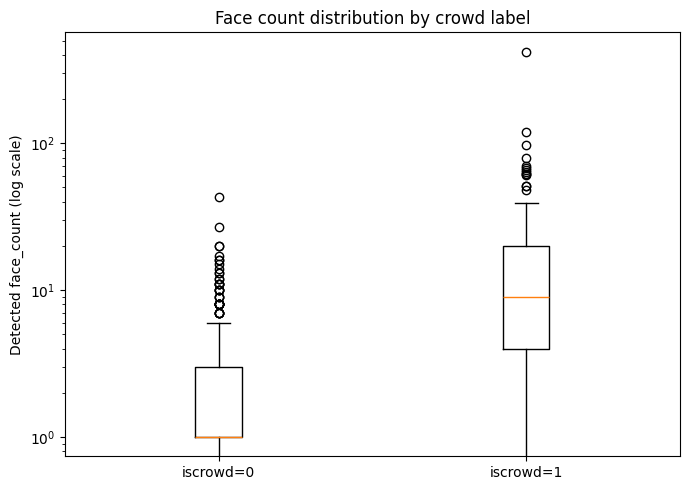

In [28]:
# Split face_count by class
fc0 = df.loc[df["y"] == 0, "face_count"].values
fc1 = df.loc[df["y"] == 1, "face_count"].values

plt.figure(figsize=(7,5))
plt.boxplot([fc0, fc1], labels=["iscrowd=0", "iscrowd=1"], showfliers=True)
plt.yscale("log")  # important because you have extreme outliers (e.g., 421)
plt.ylabel("Detected face_count (log scale)")
plt.title("Face count distribution by crowd label")
plt.tight_layout()
plt.savefig(FIG_DIR / "facecount_by_label_boxplot.png", dpi=200)
plt.show()


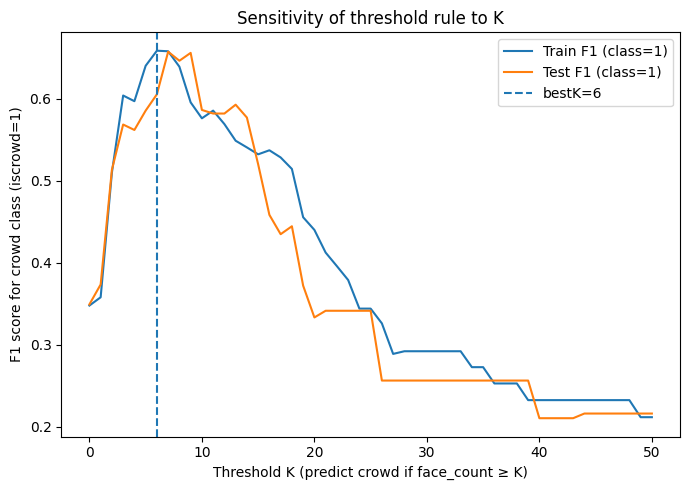

In [29]:
Ks = list(range(0, 51))

train_f1 = []
test_f1  = []

for k in Ks:
    pred_tr = rule_pred(df_train["face_count"], k)
    pred_te = rule_pred(df_test["face_count"], k)

    train_f1.append(f1_score(df_train["y"], pred_tr, pos_label=1))
    test_f1.append(f1_score(df_test["y"], pred_te, pos_label=1))

plt.figure(figsize=(7,5))
plt.plot(Ks, train_f1, label="Train F1 (class=1)")
plt.plot(Ks, test_f1,  label="Test F1 (class=1)")
plt.axvline(bestK, linestyle="--", label=f"bestK={bestK}")
plt.xlabel("Threshold K (predict crowd if face_count ≥ K)")
plt.ylabel("F1 score for crowd class (iscrowd=1)")
plt.title("Sensitivity of threshold rule to K")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "k_sweep_f1_train_test.png", dpi=200)
plt.show()


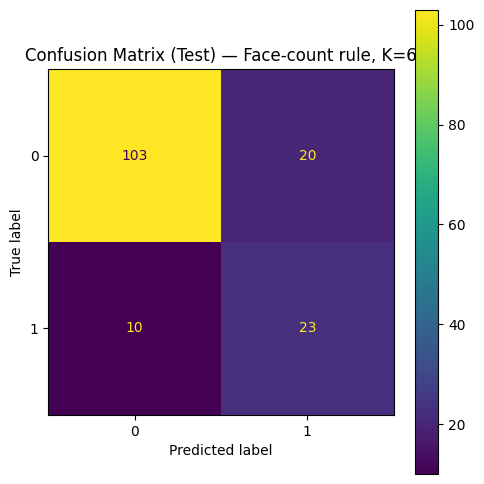

Test F1 (class=1): 0.6052631578947368
CM:
 [[103  20]
 [ 10  23]]


In [32]:
pred_te = rule_pred(df_test["face_count"], bestK)
cm = confusion_matrix(df_test["y"], pred_te, labels=[0,1])

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
fig, ax = plt.subplots(figsize=(5,5))
disp.plot(ax=ax, values_format="d")
ax.set_title(f"Confusion Matrix (Test) — Face-count rule, K={bestK}")
plt.tight_layout()
plt.savefig(FIG_DIR / f"confusion_matrix_k{bestK}_test.png", dpi=200)
plt.show()

print("Test F1 (class=1):", f1_score(df_test["y"], pred_te, pos_label=1))
print("CM:\n", cm)


In [35]:
err = df_test.copy()
err["pred_rule"] = pred_te

fp = err[(err["y"]==0) & (err["pred_rule"]==1)].sort_values("face_count", ascending=False)
fn = err[(err["y"]==1) & (err["pred_rule"]==0)].sort_values("face_count", ascending=True)

display(fp[["imageid","face_count","image_path"]].head(10))
display(fn[["imageid","face_count","image_path"]].head(10))


,imageid,face_count,image_path
15,abc-news_0014_2.jpg,43,/content/drive/MyDrive/STATS201_project/torres...
475,usa-today_0009_5.jpg,20,/content/drive/MyDrive/STATS201_project/torres...
40,al-jazeera-english_0010_2.jpg,17,/content/drive/MyDrive/STATS201_project/torres...
500,vice-news_0011_8.jpg,16,/content/drive/MyDrive/STATS201_project/torres...
256,nbc-news_0008_3.jpg,13,/content/drive/MyDrive/STATS201_project/torres...
23,abc-news_0019_6.jpg,12,/content/drive/MyDrive/STATS201_project/torres...
146,cnbc_0013_13.jpg,10,/content/drive/MyDrive/STATS201_project/torres...
399,the-wall-street-journal_0003_6.jpg,10,/content/drive/MyDrive/STATS201_project/torres...
4,abc-news_0003_3.jpg,8,/content/drive/MyDrive/STATS201_project/torres...
344,politico_0019_9.jpg,8,/content/drive/MyDrive/STATS201_project/torres...


,imageid,face_count,image_path
51,al-jazeera-english_0014_1.jpg,0,/content/drive/MyDrive/STATS201_project/torres...
227,msnbc_0016_1.jpg,0,/content/drive/MyDrive/STATS201_project/torres...
458,time_0018_5.jpg,1,/content/drive/MyDrive/STATS201_project/torres...
462,usa-today_0000_3.jpg,1,/content/drive/MyDrive/STATS201_project/torres...
449,time_0002_1.jpg,2,/content/drive/MyDrive/STATS201_project/torres...
46,al-jazeera-english_0011_9.jpg,2,/content/drive/MyDrive/STATS201_project/torres...
136,cnbc_0009_8.jpg,3,/content/drive/MyDrive/STATS201_project/torres...
195,fox-news_0001_4.jpg,3,/content/drive/MyDrive/STATS201_project/torres...
239,national-review_0011_1.jpg,4,/content/drive/MyDrive/STATS201_project/torres...
93,breitbart-news_0008_26.jpg,5,/content/drive/MyDrive/STATS201_project/torres...
